<a href="https://colab.research.google.com/github/Himanshu-86/ML_2026/blob/main/Practical_13_PCA_Logistic_Regression_Malnutrition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 13: PCA + Logistic Regression – Malnutrition Prediction

## Objective
To reduce dimensionality using PCA and build a Logistic Regression model to predict malnutrition risk.

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Load Dataset

In [ ]:
df = pd.read_csv("sdg_malnutrition_dataset.csv")
print(df.shape)
df.head()

(100000, 41)


,Household_Income,Poverty_Status,Food_Expenditure_Ratio,Social_Protection_Access,Food_Availability,Dietary_Diversity_Score,Meal_Frequency,Child_Feeding_Practices,Child_Health_Status,Immunization_Status,...,Access_To_Services_Equity,Housing_Condition,Slum_Residence,Population_Density,Food_Wastage_Level,Food_Storage_Practices,Climate_Shock_Exposure,Crop_Failure_Incidence,Weather_Variability,Malnutrition_Risk
0,28236.114017,0,0.663549,1,0.683364,8,1,0.258585,0.791974,0,...,0.474607,0.940448,0,13379,0.860530,0.335483,0,0,0.005176,0
1,20555.171637,0,0.456270,1,0.831084,5,2,0.944793,0.665151,1,...,0.276406,0.732535,0,14585,0.165408,0.230523,0,0,0.408611,0
2,30450.091226,0,0.493708,1,0.825048,7,2,0.655804,0.364330,1,...,0.539590,0.421672,1,4186,0.038422,0.199440,1,1,0.122318,0
3,47170.073204,1,0.592818,1,0.514674,5,4,0.768238,0.327269,1,...,0.373299,0.482478,0,14713,0.504149,0.906650,1,0,0.808787,0
4,19592.915242,0,0.469154,0,0.772103,9,4,0.196116,0.162214,1,...,0.093860,0.489095,1,14006,0.435767,0.782797,0,0,0.251836,0


## Clean Column Names

In [ ]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.lower()

print(df.columns)

Index(['household_income', 'poverty_status', 'food_expenditure_ratio',
       'social_protection_access', 'food_availability',
       'dietary_diversity_score', 'meal_frequency', 'child_feeding_practices',
       'child_health_status', 'immunization_status', 'disease_incidence',
       'maternal_health_status', 'mother_education_level',
       'nutrition_awareness', 'school_attendance',
       'women_decision_making_index', 'early_marriage_indicator',
       'maternal_autonomy', 'access_to_clean_water',
       'sanitation_facility_type', 'hygiene_practices', 'cooking_fuel_type',
       'electricity_access', 'employment_status', 'job_stability',
       'household_working_members', 'healthcare_facility_access',
       'road_accessibility', 'market_access', 'income_inequality_index',
       'social_inclusion_index', 'access_to_services_equity',
       'housing_condition', 'slum_residence', 'population_density',
       'food_wastage_level', 'food_storage_practices',
       'climate_shock_e

## Identify Target Column

In [ ]:
target_col = [col for col in df.columns if 'malnutrition' in col or 'risk' in col][0]
print("Target column:", target_col)

Target column: malnutrition_risk


## Feature & Target Split

In [ ]:
X = df.drop(target_col, axis=1)
y = df[target_col]

## Feature Scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Apply PCA

In [ ]:
pca = PCA(n_components=0.95)  # retain 95% variance
X_pca = pca.fit_transform(X_scaled)

print("Original Features:", X.shape[1])
print("Reduced Features:", X_pca.shape[1])

Original Features: 40
Reduced Features: 38


## Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

## Train Logistic Regression Model

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Prediction

In [ ]:
y_pred = model.predict(X_test)

## Model Evaluation

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9994

Confusion Matrix:
 [[19957     6]
 [    6    31]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     19963
           1       0.84      0.84      0.84        37

    accuracy                           1.00     20000
   macro avg       0.92      0.92      0.92     20000
weighted avg       1.00      1.00      1.00     20000



## PCA Explained Variance

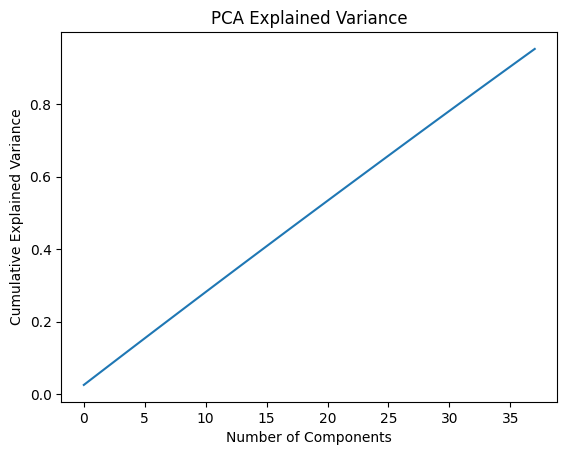

In [ ]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

## Conclusion

PCA successfully reduced dimensionality while retaining important information. Logistic Regression effectively predicted malnutrition risk using reduced features.